# 04. cuPF CPU: 같은 Newton step에서 무엇을 바꾸는가

cuPF CPU path는 GPU로 가기 전의 비교 기준이다. 여기서 새 수학을 푸는 것이 아니다. 02에서 본 같은 reduced Newton system을 두 지점에서 최적화한다.

1. `J dx = -F`를 푸는 sparse solver 선택
2. Jacobian sparse pattern을 알고 있다는 사실의 재사용

`cpu_umfpack.cpp`와 `cpu_klu.cpp`는 Newton pipeline 안에서 linear solve backend 역할을 한다. UMFPACK은 pandapower/SciPy의 SuiteSparse 계열 비교점에 가깝고, KLU는 회로형 sparse system에 특화된 solver로 보는 것이 자연스럽다.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'cuPF').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from python.tutorial import tutorial_utils as tu

plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['axes.grid'] = False
pd.set_option('display.max_colwidth', 120)

TUTORIAL_CASE = tu.TUTORIAL_LARGE_CASE
RUN_BENCHMARKS = True
REPEATS = 1
WARMUP = 0


In [2]:
display(pd.DataFrame([
    {'variant': 'cupf-cpu-umfpack-pandapower-jac', 'meaning': 'pandapower-like Jacobian + UMFPACK linear solve'},
    {'variant': 'cupf-cpu-klu-pandapower-jac', 'meaning': 'same Jacobian formula, KLU linear solve'},
    {'variant': 'cupf-cpu-klu', 'meaning': 'native fixed-pattern Jacobian fill + KLU'},
]))
case = tu.load_case(TUTORIAL_CASE)
print(f"case={case.case_name}, buses={case.ybus.shape[0]}, ybus_nnz={case.ybus.nnz}")


,variant,meaning
0,cupf-cpu-umfpack-pandapower-jac,pandapower-like Jacobian + UMFPACK linear solve
1,cupf-cpu-klu-pandapower-jac,"same Jacobian formula, KLU linear solve"
2,cupf-cpu-klu,native fixed-pattern Jacobian fill + KLU


case=case6468rte, buses=6468, ybus_nnz=22598


빌드는 결과 해석의 본문이 아니다. 다만 이 노트북은 후임자가 같은 환경에서 다시 돌릴 수 있어야 하므로, CPU evaluator를 여기서 준비한다.


In [3]:
build = tu.build_eval('cpu', jobs=2, timeout=2400)
print(tu.command_summary(build, tail_lines=16))


$ bash benchmark/scripts/build_eval.bash cpu --jobs 2
[OK] elapsed=0.2s
-- spdlog not found: disabling cuPF logging
-- Found pybind11: /usr/local/include (found version "3.0.1")
-- Configuring done
-- Generating done
-- Build files have been written to: /workspace/gpu-powerflow-master/cuPF/build/eval-cpu
[build_eval] build _cupf + cupf_cpp_evaluate (-j 2)
Consolidate compiler generated dependencies of target cupf
[ 87%] Built target cupf
Consolidate compiler generated dependencies of target _cupf
[100%] Built target _cupf
[ 82%] Built target cupf
Consolidate compiler generated dependencies of target cupf_cpp_evaluate
[100%] Built target cupf_cpp_evaluate
[build_eval] done. artifacts under /workspace/gpu-powerflow-master/cuPF/build/eval-cpu
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-cpu/tests/cupf_cpp_evaluate
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-cpu/_cupf.cpython-310-x86_64-linux-gnu.so


비교 순서는 일부러 “UMFPACK 기준 -> KLU -> native Jacobian”으로 둔다. 그래야 solver 교체와 Jacobian fill 교체를 분리해서 읽을 수 있다.


$ /usr/bin/python3 -m python.tests.run_benchmark --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --run-name tutorial-cpu-20260601-132542 --cases case6468rte --repeats 1 --warmup 0 --variants cupf-cpu-umfpack-pandapower-jac-pybind cupf-cpu-klu-pandapower-jac-pybind cupf-cpu-klu-pybind
[OK] elapsed=11.2s
[benchmark][RUN] /usr/bin/python3 -m python.tests.run_cupf_pybind --dataset-root /datasets/matpower --run-name tutorial-cpu-20260601-132542 --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --warmup 0 --repeats 1 --tolerance 1e-08 --max-iter 50 --reference-tolerance 1e-10 --reference-max-iter 80 --no-aggregate --cases case6468rte --variants cupf-cpu-klu-pandapower-jac-pybind cupf-cpu-klu-pybind cupf-cpu-umfpack-pandapower-jac-pybind
[cupf-cpu-klu-pybind][OK] case6468rte repeat=0 init_ms=7.777 solve_ms=12.090 iters=4 resid=1.341e-11
[cupf-cpu-klu-pybind] wrote /workspace/gpu-powerflow-master/python/tutorial/_runs/tutorial-cpu-20260601-132542/cupf-cpu-

,variant,linear_solver,jacobian,initialize_ms,solve_ms,worst_residual
0,cupf-cpu-klu-pandapower-jac-pybind,klu,pandapower,7.797291,12.068173,1.340572e-11
1,cupf-cpu-klu-pybind,klu,native,7.777353,12.090175,1.340572e-11
2,cupf-cpu-umfpack-pandapower-jac-pybind,umfpack,pandapower,9.533684,59.535760,1.015891e-11


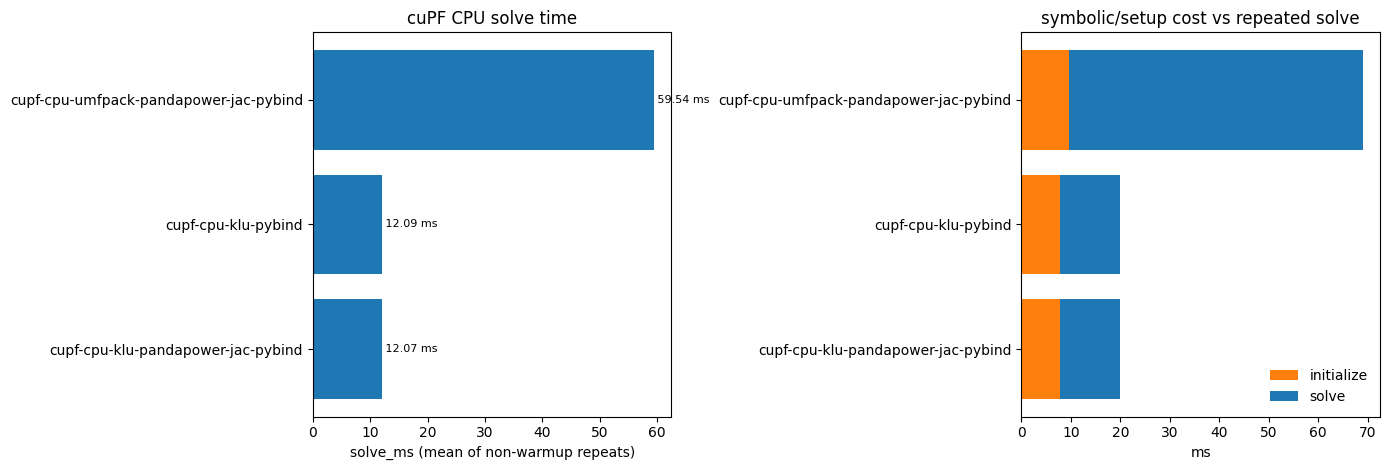

In [4]:
variants = [
    'cupf-cpu-umfpack-pandapower-jac-pybind',
    'cupf-cpu-klu-pandapower-jac-pybind',
    'cupf-cpu-klu-pybind',
]
if RUN_BENCHMARKS and build.ok:
    run_dir, command = tu.run_tutorial_benchmark(
        variants=variants,
        run_name=tu.timestamp_run_name('tutorial-cpu'),
        cases=[TUTORIAL_CASE],
        repeats=REPEATS,
        warmup=WARMUP,
        timeout=3600,
    )
    print(tu.command_summary(command, tail_lines=18))
else:
    run_dir = tu.tutorial_output_root()
    print('CPU benchmark was not run because the build did not complete or RUN_BENCHMARKS=False.')

summary = tu.benchmark_result_table(run_dir)
display(summary[['variant', 'linear_solver', 'jacobian', 'initialize_ms', 'solve_ms', 'worst_residual']])
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
tu.plot_variant_timing(summary, axes[0], 'cuPF CPU solve time')
tu.plot_init_solve_stack(summary, axes[1], 'symbolic/setup cost vs repeated solve')
plt.tight_layout()


결과를 볼 때 `initialize_ms`와 `solve_ms`를 같이 봐야 한다. sparse direct solver는 symbolic analysis와 numeric factorization의 비용 구조가 다르다. Newton iteration에서 값은 매번 바뀌지만 pattern은 유지되므로, cuPF의 CPU path는 이 반복 구조를 더 직접적으로 활용하려고 한다.
